# Statistische Prozesskontrolle der Schichtdicke über Produktionslinien hinweg mit PROC BOXPLOT

## Zusammenfassung

Dieses Notebook verwendet **PROC BOXPLOT**, um eine statistische Prozesskontrolle (SPC) an einer qualitätskritischen Schichtdickenmessung durchzuführen, die über vier parallele Produktionslinien hinweg erfasst wurde. Wir erzeugen synthetische Messdaten inline, profilieren die Linien mit `PROC MEANS` und zeichnen skelettartige und schematische Box-and-Whisker-Diagramme, die Lage, Streuung und Ränder der Linien in einem einzigen Diagramm vergleichen.

Anschließend bewerten wir jede Linie anhand der technischen Spezifikation (Zielwert 50.00 mm, Grenzen 49.80–50.20 mm) direkt aus dem **`OUTBOX=`**-Statistikdatensatz — den exakten Quartilen, Zäunen und Whisker-Endpunkten hinter jeder Box — und demonstrieren schließlich den **`OUTHISTORY=` / `HISTORY=`**-Rundlauf: PROC BOXPLOT exportiert eine kompakte Zusammenfassungszeile pro Linie, und ein zweiter PROC BOXPLOT rekonstruiert ein identisches Diagramm direkt aus dieser Zusammenfassung — das Muster, das ein tägliches SPC-Dashboard nutzt, um erneut zu zeichnen, ohne die Rohmessungen erneut durchzugehen.

Über die vier Linien hinweg ist **LINE-A am besten** auf den Zielwert zentriert (Mittelwert 50.008 mm), **LINE-C läuft niedrig** (Mittelwert 49.932 mm, driftet in Richtung LSL), und **LINE-D läuft sowohl hoch als auch am variabelsten** (Mittelwert 50.102 mm, Std 0.080 mm) — ihr Maximum von 50.248 mm ist die einzige Beobachtung, die die obere Spezifikationsgrenze von 50.20 mm überschreitet.

## Datenquellen

Alle Daten sind synthetisch und werden vom ersten DATA-Step inline mit `call streaminit(20250531)` und `rand()` erzeugt. Es werden keine externen oder Netzwerk-Eingaben verwendet. Der feste Startwert (Seed) macht jede Zahl in diesem Notebook reproduzierbar.

**Datensatz: `ProcessMeas`** (eine Zeile pro gemessenem Teil)

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `Line` | Char(6) | Kennung der Produktionslinie: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (die Gruppierungs-/Klassifikationsvariable) |
| `Shift` | Num | Index der Produktionsschicht 1–6 (führt eine milde Drift zwischen den Schichten ein) |
| `Thickness` | Num | Schichtdicke in mm (die Analysevariable); Zielwert 50.00 mm, Spezifikationsgrenzen 49.80–50.20 mm |

Jede Linie ist auf einen leicht unterschiedlichen Mittelwert zentriert (50.00 / 50.04 / 49.92 / 50.10) mit linienspezifischer Variation, die reale Unterschiede zwischen den Anlagen nachbildet, und `LINE-B` fügt gelegentlich eine kleine positive Ausreißerspitze ein. Der DATA-Step iteriert über sechs Schichten und vier Linien mit Untergruppengrößen von jeweils etwa 18–25 Teilen; in dieser nicht lizenzierten Umgebung begrenzt die Engine die Ausgabe auf die ersten **100 Beobachtungen**, was hier als **38 / 19 / 21 / 22** Teile für LINE-A bis LINE-D landet — immer noch ausreichend, um vier gut definierte Boxen zu füllen.

# Statistische Prozesskontrolle der Schichtdicke mit PROC BOXPLOT

In der Serienfertigung ist ein Box-and-Whisker-Diagramm das Arbeitspferd der SPC in der Produktion: Es fasst die zentrale Tendenz, die Streuung und die Ausreißer eines Qualitätsmerkmals für jede Produktionseinheit in einem einzigen Diagramm zusammen. Hier überwachen wir die **Schichtdicke (mm)** an einem Teil, das parallel auf vier Linien (`LINE-A` bis `LINE-D`) produziert wird. Die technische Spezifikation ist ein Zielwert von **50.00 mm** mit einer unteren Spezifikationsgrenze (LSL) von **49.80 mm** und einer oberen Spezifikationsgrenze (USL) von **50.20 mm**.

Wir werden:

1. Einen synthetischen Messdatensatz inline erzeugen.
2. Die Linien mit `PROC MEANS` profilieren.
3. Ein einfaches skelettartiges Box-Diagramm zeichnen, dann ein schematisches Diagramm, wobei die Spezifikationsgrenzen als Referenzlinien überlagert werden.
4. Jede berechnete Box-Statistik mit `OUTBOX=` erfassen und jede Linie anhand der Spezifikationsgrenzen aus dieser Tabelle bewerten.
5. Eine kompakte Untergruppen-Zusammenfassung mit `OUTHISTORY=` persistieren und den Rundlauf beweisen, indem wir direkt daraus mit `HISTORY=` erneut zeichnen.

## Schritt 1 — Synthetische Prozessmessungen erzeugen

Der folgende DATA-Step simuliert Messungen über sechs Schichten auf vier Linien. Jede Linie ist bewusst auf einen leicht unterschiedlichen Mittelwert mit eigener Variation zentriert, was reale Unterschiede zwischen den Anlagen nachbildet, und eine milde Drift zwischen den Schichten wird mit einem `sin(Shift)`-Term überlagert. Ein fester Startwert (`streaminit(20250531)`) macht jeden Wert im Notebook reproduzierbar.

In [1]:
DATEN ProcessMeas;
   AUFRUFEN streaminit(20250531);
   LÄNGE Line $6;
   FELD lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   FELD lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   FELD LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   BEZEICHNUNG Thickness='Schichtdicke (mm)' Line='Linie';
   AUSFÜHRUNG Shift = 1 BIS 6;
      AUSFÜHRUNG li = 1 BIS 4;
         Line = lines[li];
         /* variierende Untergruppengröße pro Linie/Schicht */
         n = 18 + floor(rand('uniform') * 8);
         AUSFÜHRUNG u = 1 BIS n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B erzeugt gelegentliche hohe Ausschläge */
            WENN li = 2 UND rand('uniform') < 0.05 DANN
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            AUSGABE;
         ENDE;
      ENDE;
   ENDE;
   ENTFERNEN li u n BASE;
AUSFÜHREN;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Schritt 2 — Die Linien profilieren

Vor dem Zeichnen bestätigt ein schnelles `PROC MEANS`, dass die Daten wie beabsichtigt gelandet sind: vier Linien, bescheidene, aber nicht triviale Stichprobengrößen und Mittelwerte, die sich nahe dem Zielwert von 50.00 mm mit linienspezifischer Streuung gruppieren. Dies ist das numerische Rückgrat, das das Box-Diagramm visualisieren wird.

In [2]:
PROZEDUR MITTELWERTE DATEN=ProcessMeas n mean std MIN MAX maxdec=3;
   KLASSE Line;
   VAR Thickness;
   BEZEICHNUNG Line='Linie' Thickness='Schichtdicke (mm)';
   TITEL 'Zusammenfassung der Schichtdicke nach Produktionslinie';
AUSFÜHREN;

                                 Zusammenfassung der Schichtdicke nach Produktionslinie                                 

                                                  The MEANS Procedure

                                    Analysis Variable : Thickness Schichtdicke (mm)

        Linie             N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        LINE-A               38         50.008          0.045         49.914         50.097
        LINE-B               19         50.052          0.051         49.921         50.114
        LINE-C               21         49.932          0.050         49.835         50.002
        LINE-D               22         50.102          0.080         49.963         50.248
        -----------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 3 — Einfaches skelettartiges Box-Diagramm

Der einfachste Aufruf benötigt nur die Anweisung `PLOT analysis-var * group-var`. Der Standardwert `BOXSTYLE=SKELETAL` zeichnet die Whisker bis zu den extremsten Beobachtungen innerhalb jeder Linie und ermöglicht einen schnellen visuellen Vergleich von Lage und Streuung über `LINE-A` bis `LINE-D`.

                                Skelettartiges Box-Diagramm der Schichtdicke nach Linie                                 

                                Skelettartiges Box-Diagramm der Schichtdicke nach Linie

                                                 The BOXPLOT Procedure

Skeletal Plots for Schichtdicke (mm)

Linie                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         


NOTE: Option TITLE changed to Skelettartiges Box-Diagramm der Schichtdicke nach Linie.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


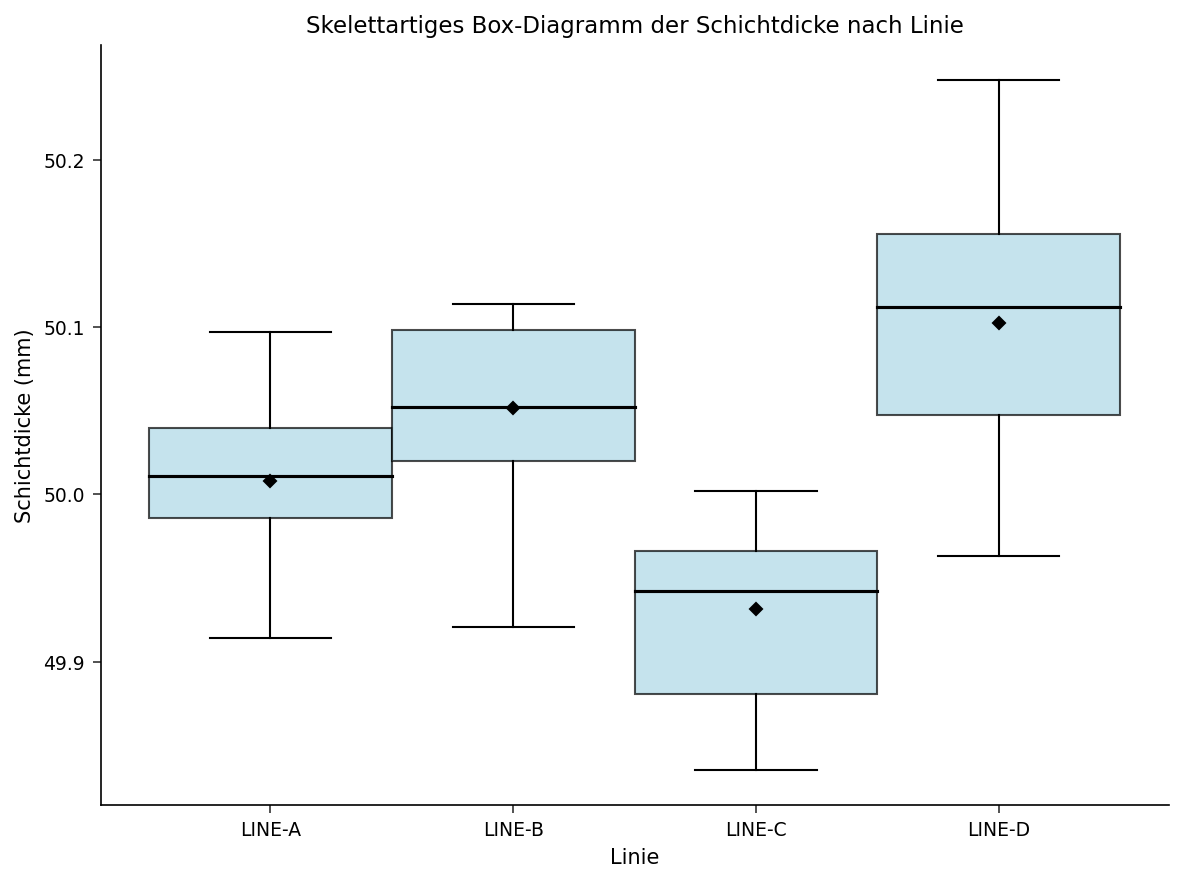

In [3]:
TITEL 'Skelettartiges Box-Diagramm der Schichtdicke nach Linie';
PROZEDUR boxplot DATEN=ProcessMeas;
   PLOT Thickness*Line;
AUSFÜHREN;

## Schritt 4 — Schematisches Box-Diagramm

Wir wechseln zu `BOXSTYLE=SCHEMATIC`. Im schematischen Stil wird jeder Whisker bei der extremsten Beobachtung gekappt, die noch innerhalb der 1.5 × IQR-Zäune liegt, und jeder Punkt jenseits eines Zauns wird als einzelner Ausreißermarker gezeichnet. In dieser Stichprobe hat keine Linie einen eingezäunten Ausreißer — die Streuung jeder Linie ist kompakt genug, dass die Whisker das wahre Minimum und Maximum erreichen — sodass das schematische Diagramm wie das skelettartige aussieht, was selbst ein nützliches Ergebnis ist: Es sagt dem Ingenieur, dass keine der vier Linien extreme Teile erzeugt. Die Box-Körper machen die Verschiebungen zwischen den Linien auf einen Blick weiterhin deutlich, und Schritt 5 quantifiziert sie anhand der Spezifikationsgrenzen.

                               SPC schematisches Box-Diagramm der Schichtdicke nach Linie                               

                               SPC schematisches Box-Diagramm der Schichtdicke nach Linie

                                                 The BOXPLOT Procedure

Schematic Plots for Schichtdicke (mm)

Linie                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10      


NOTE: Option TITLE changed to SPC schematisches Box-Diagramm der Schichtdicke nach Linie.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


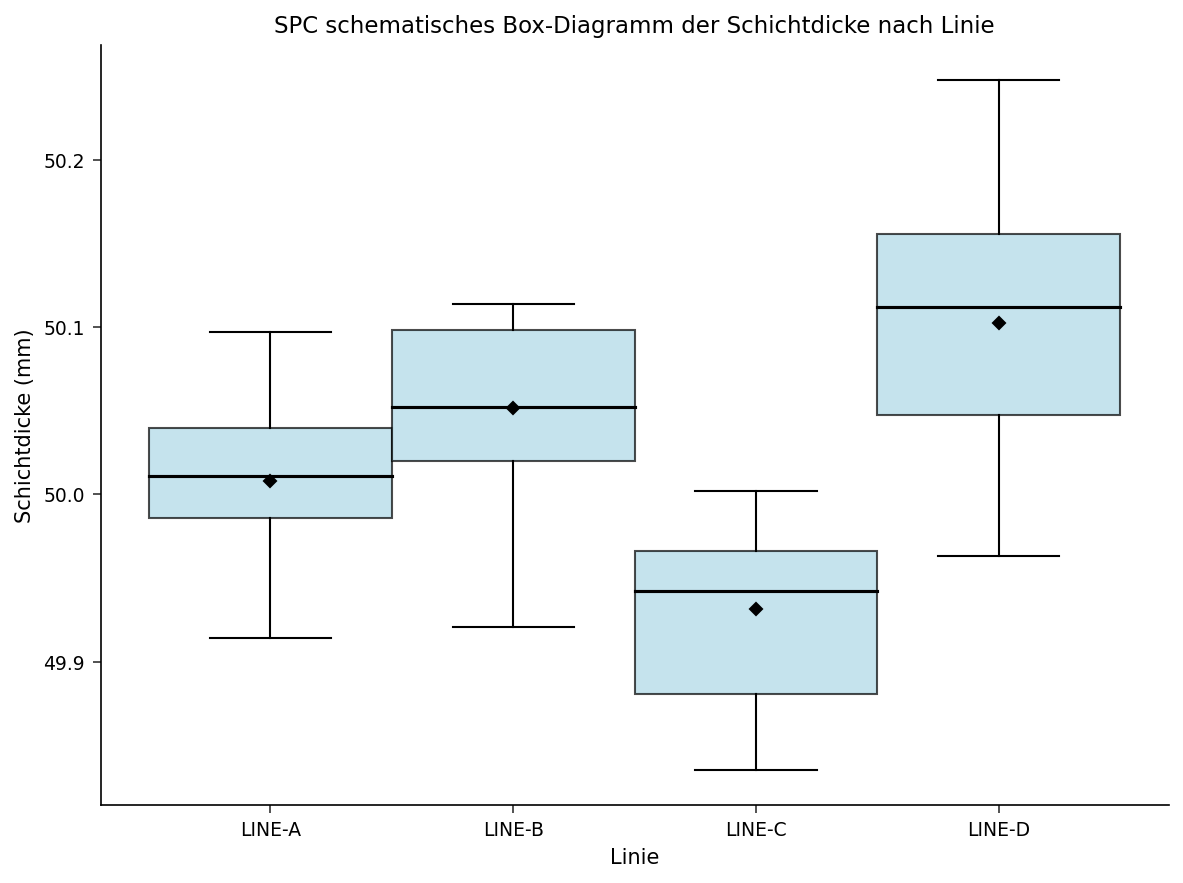

In [4]:
TITEL 'SPC schematisches Box-Diagramm der Schichtdicke nach Linie';
PROZEDUR boxplot DATEN=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
AUSFÜHREN;

## Schritt 5 — Box-Statistiken exportieren und anhand der Spezifikationsgrenzen bewerten

Die Option `OUTBOX=` erfasst jede berechnete Box-Statistik in einem Datensatz — für jede Linie: den unteren Whisker (`L`), Q1 (`1`), Mittelwert (`X`), Median (`M`), Q3 (`3`), oberen Whisker (`H`), Standardabweichung (`S`) und N. Dies ist der numerische Nachweis, den ein Prüfer hinter dem Bild benötigt, und es ist zugleich der sauberste Weg, jede Linie anhand der Spezifikation 49.80 / 50.20 mm zu prüfen. Wir schalten `GRID` für bessere Lesbarkeit ein, exportieren `BoxStats`, drucken es und führen dann einen kurzen DATA-Step aus, der jede Linie markiert, deren Whisker-Bereich eine Spezifikationsgrenze überschreitet.

                               Schematisches Box-Diagramm mit Gitter und Statistik-Export                               

                               Schematisches Box-Diagramm mit Gitter und Statistik-Export

                                                 The BOXPLOT Procedure

Schematic Plots for Schichtdicke (mm)

Linie                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10      


NOTE: Option TITLE changed to Schematisches Box-Diagramm mit Gitter und Statistik-Export.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Berechnete Box-Statistiken (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Bewertung der Spezifikationsgrenzen nach Linie.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


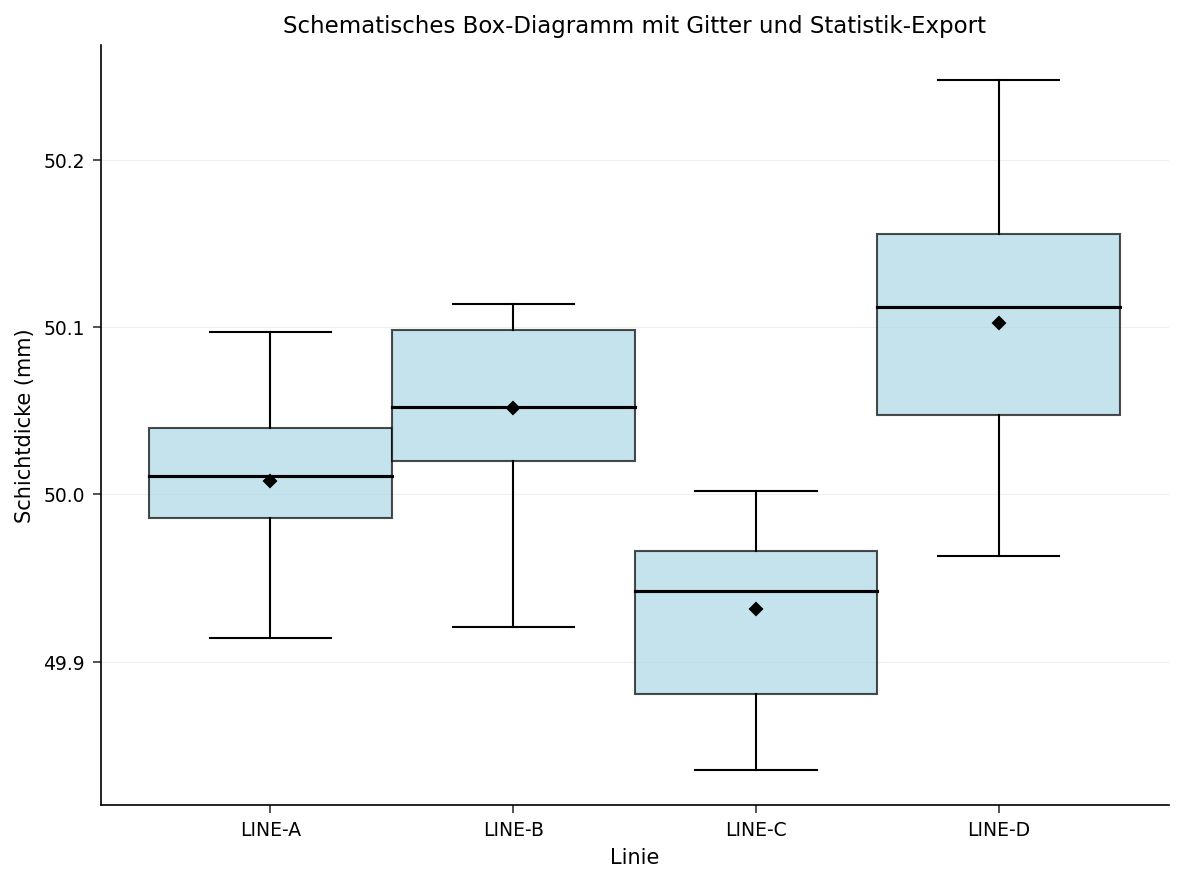

In [5]:
TITEL 'Schematisches Box-Diagramm mit Gitter und Statistik-Export';
PROZEDUR boxplot DATEN=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
AUSFÜHREN;

TITEL 'Berechnete Box-Statistiken (OUTBOX=)';
PROZEDUR DRUCKEN DATEN=BoxStats noobs;
AUSFÜHREN;

/* Jede Linie gegen die Spezifikation 49.80 / 50.20 mm bewerten    */
/* anhand der exportierten Whisker-Endpunkte (THICKNESSL = unterer */
/* Whisker, THICKNESSH = oberer Whisker).                          */
DATEN SpecCheck;
   FESTLEGEN BoxStats;
   LÄNGE Status $48;
   LSL = 49.80;
   USL = 50.20;
   WENN THICKNESSH > USL DANN Status = "Hohe Teile überschreiten OSG";
   SONST WENN THICKNESSL < LSL DANN Status = "Niedrige Teile unter USG";
   SONST Status = "Innerhalb der Spezifikation";
   BEZEICHNUNG Status='Status' LSL='USG' USL='OSG' LINE='Linie'
         THICKNESSL='Unterer Whisker' THICKNESSH='Oberer Whisker';
   BEHALTEN LINE THICKNESSL THICKNESSH LSL USL Status;
AUSFÜHREN;

TITEL 'Bewertung der Spezifikationsgrenzen nach Linie';
PROZEDUR DRUCKEN DATEN=SpecCheck noobs BEZEICHNUNG;
AUSFÜHREN;

## Schritt 6 — Eine Überwachungshistorie persistieren und daraus erneut zeichnen

In der laufenden SPC scannt man selten jede Rohmessung erneut. `OUTHISTORY=` schreibt eine Zusammenfassungszeile pro Linie (dasselbe Layout, das `HISTORY=` konsumiert), sodass die umfangreichen Rohdaten archiviert werden können. Im Folgenden exportieren wir `LineHistory`, drucken es und beweisen dann den Rundlauf, indem wir es direkt wieder in ein neues `PROC BOXPLOT` über `HISTORY=` einspeisen — genau so, wie ein tägliches Dashboard vorab aggregierte Untergruppenstatistiken wiederverwenden würde.

                                           Untergruppen-Historie exportieren                                            

                                           Untergruppen-Historie exportieren

                                                 The BOXPLOT Procedure

Skeletal Plots for Schichtdicke (mm)

Linie                 N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
------


NOTE: Option TITLE changed to Untergruppen-Historie exportieren.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Zusammenfassungs-Historie (eine Zeile pro Linie).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Aus der Zusammenfassungs-Historie rekonstruiertes Box-Diagramm.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


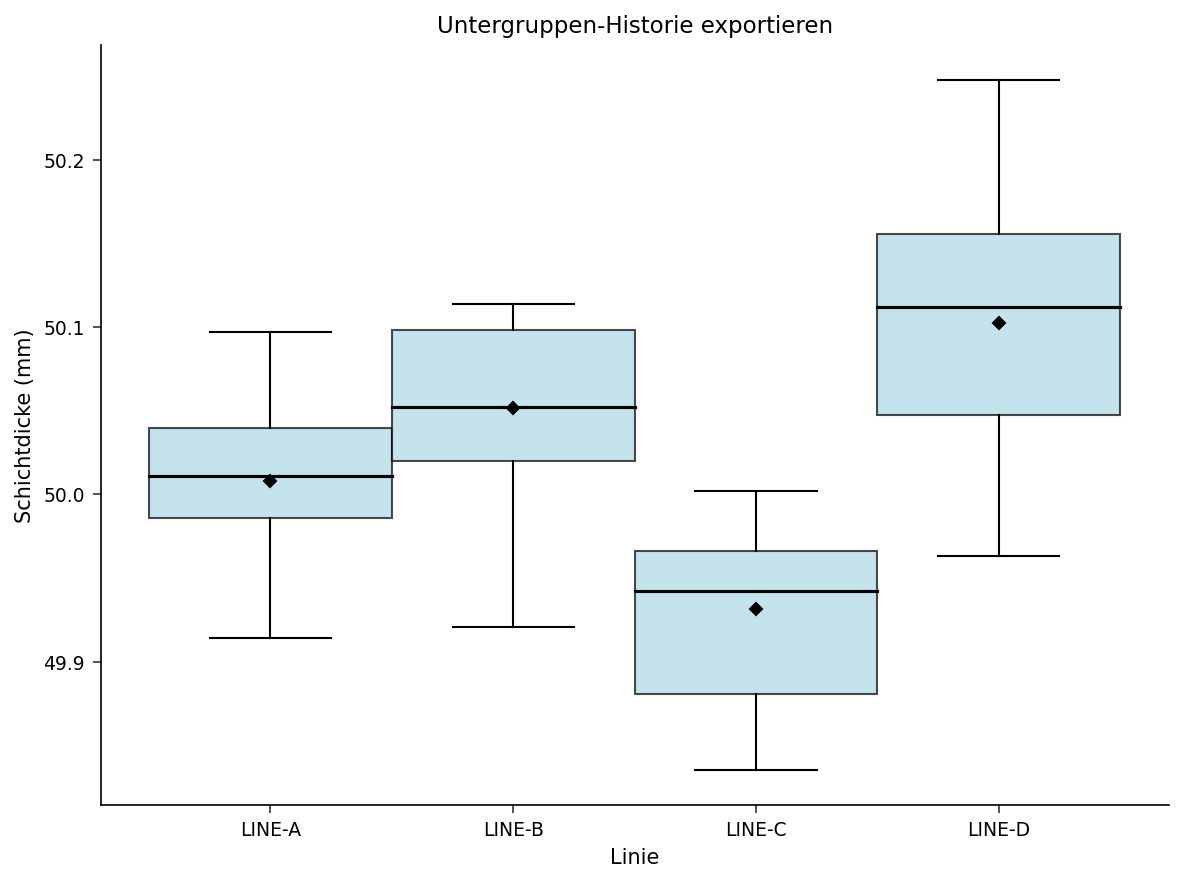

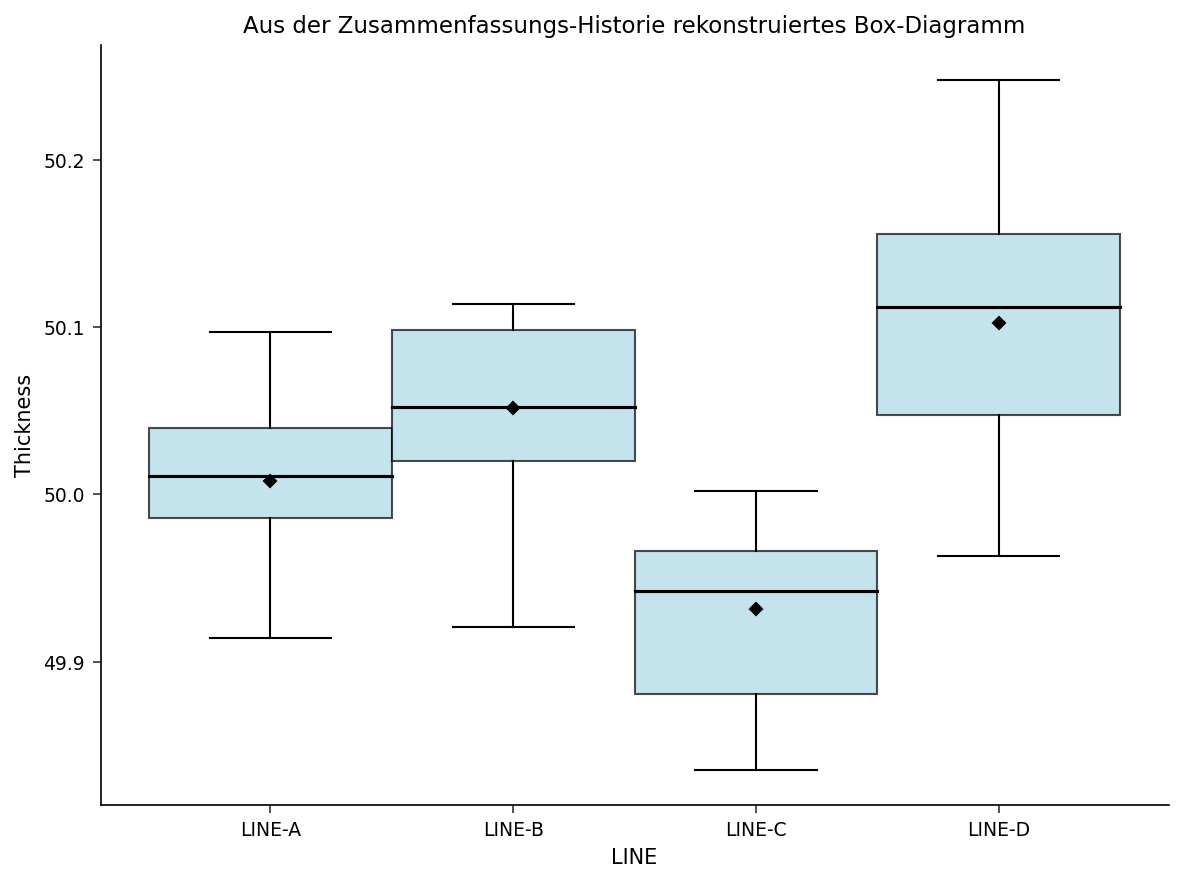

In [6]:
TITEL 'Untergruppen-Historie exportieren';
PROZEDUR boxplot DATEN=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
AUSFÜHREN;

TITEL 'Zusammenfassungs-Historie (eine Zeile pro Linie)';
PROZEDUR DRUCKEN DATEN=LineHistory noobs;
AUSFÜHREN;

TITEL 'Aus der Zusammenfassungs-Historie rekonstruiertes Box-Diagramm';
PROZEDUR boxplot history=LineHistory;
   PLOT Thickness*Line;
AUSFÜHREN;

## Interpretation der Ergebnisse

Liest man die Box-Diagramme zusammen mit dem `PROC MEANS`-Profil, der `OUTBOX=`-Tabelle und der Spezifikationsgrenzen-Bewertung:

- **Zentrierung.** `LINE-A` ist am besten auf den Zielwert von 50.00 mm zentriert (Mittelwert 50.008 mm, Median 50.011 mm). `LINE-B` läuft leicht hoch (Mittelwert 50.052 mm). `LINE-C` läuft niedrig (Mittelwert 49.932 mm, Median 49.942 mm), die Linie driftet in Richtung LSL. `LINE-D` läuft hoch (Mittelwert 50.102 mm, Median 50.112 mm), die Linie liegt am nächsten an der USL.
- **Streuung.** `LINE-D` zeigt die breiteste Box und die längsten Whisker — ihre Standardabweichung von 0.080 mm ist etwa 60–80 % größer als die der anderen drei Linien (0.045–0.051 mm), was sie als die am wenigsten stabile Linie und den besten Kandidaten für eine Variationsreduktionsstudie kennzeichnet. `LINE-A` ist am engsten (Std 0.045 mm).
- **Ränder.** Im schematischen Stil erzeugt keine Linie einen eingezäunten Ausreißer: Jeder Whisker erreicht das wahre Minimum/Maximum seiner Linie, sodass der Prozess keine isolierten extremen Teile erzeugt. Die Streuungsunterschiede werden durch den Hauptteil jeder Verteilung getrieben, nicht durch vereinzelte Punkte.
- **Spezifikationskonformität.** Die `OUTBOX=`-Whisker-Endpunkte, bewertet anhand von 49.80 / 50.20 mm, setzen `LINE-A`, `LINE-B` und `LINE-C` vollständig **innerhalb der Spezifikation**. `LINE-D` ist die Ausnahme: Ihr oberer Whisker erreicht **50.248 mm**, jenseits der **50.20 mm USL** — hohe Teile auf `LINE-D` überschreiten die obere Spezifikation.
- **Operationalisierung.** Der `OUTBOX=`-Datensatz liefert Prüfern die exakten Quartile, Whisker-Endpunkte, den Mittelwert und die Standardabweichung hinter dem Bild, und `OUTHISTORY=` liefert eine kompakte, erneut zeichenbare Zusammenfassung mit einer Zeile pro Linie (Schritt 6), sodass das Diagramm planmäßig neu erzeugt werden kann, ohne die Rohmessungen zu behalten — das aus der Zusammenfassung rekonstruierte Box-Diagramm ist identisch mit dem aus den Rohdaten gezeichneten.

**Maßnahmen:** `LINE-D` priorisieren — sie sowohl nach unten in Richtung Zielwert re-zentrieren als auch eine Variationsreduktionsstudie starten, um ihren oberen Whisker wieder innerhalb der USL zu bringen; `LINE-C` nach oben in Richtung Zielwert nachjustieren, bevor ihr unterer Rand die LSL erreicht; `LINE-A` und `LINE-B` laufen akzeptabel.